# 股市資料探索
確認 PostgreSQL 資料格式與完整性

In [6]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="stock_system",
    user="aditi",
    password=""
)

In [7]:
# 讀取資料
df = pd.read_sql("SELECT * FROM prices_daily ORDER BY date", conn)
print(f"總筆數：{len(df)}")
print(f"股票清單：{df['symbol'].unique()}")
print(f"日期範圍：{df['date'].min()} 到 {df['date'].max()}")
df.head()

總筆數：487
股票清單：<StringArray>
['0050.TW', '2330.TW']
Length: 2, dtype: str
日期範圍：2025-04-10 到 2026-04-10


/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2777276450.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM prices_daily ORDER BY date", conn)


,id,symbol,date,open,high,low,close,volume,created_at
0,244,0050.TW,2025-04-10,39.3631,39.3631,39.3631,39.3631,22371068,2026-04-12 15:44:02.444129
1,1,2330.TW,2025-04-10,850.3119,850.3119,850.3119,850.3119,19416428,2026-04-12 15:44:02.444129
2,2,2330.TW,2025-04-11,835.5324,875.9296,823.7089,875.9296,76103586,2026-04-12 15:44:02.444129
3,245,0050.TW,2025-04-11,38.4941,40.2811,38.0290,40.2811,189919436,2026-04-12 15:44:02.444129
4,3,2330.TW,2025-04-14,881.8414,889.7238,852.2825,852.2825,66326054,2026-04-12 15:44:02.444129


In [8]:
# 檢查缺值
df.isnull().sum()

id            0
symbol        0
date          0
open          0
high          0
low           0
close         0
volume        0
created_at    0
dtype: int64

/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2205879125.py:11: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2205879125.py:11: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2205879125.py:11: UserWarning: Glyph 20729 (\N{CJK UNIFIED IDEOGRAPH-50F9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2205879125.py:11: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/vm5swc6d03jg3bb3x5qh30xw0000gn/T/ipykernel_54218/2205879125.py:11: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/yl/vm5s

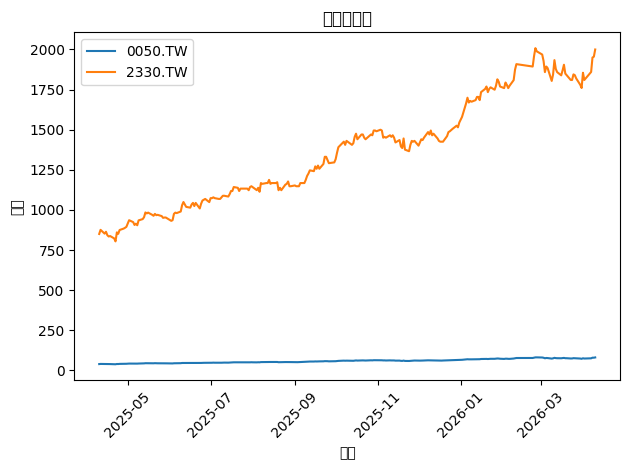

In [9]:
# 畫收盤價折線圖
for symbol in df['symbol'].unique():
    subset = df[df['symbol'] == symbol]
    plt.plot(subset['date'], subset['close'], label=symbol)

plt.title("收盤價走勢")
plt.xlabel("日期")
plt.ylabel("價格")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# 關閉連線
conn.close()
print("完成！")

完成！
